# Lab 2 — Bug trend by product


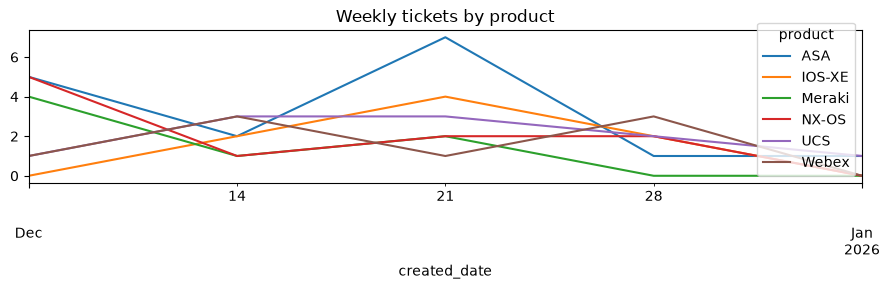

In [1]:
from pathlib import Path

import pandas as pd

GH_ROOT = Path.cwd().resolve()
if GH_ROOT.name == "notebooks":
    GH_ROOT = GH_ROOT.parents[2]
else:
    for p in [GH_ROOT, *GH_ROOT.parents]:
        if (p / "data" / "support-ops").is_dir():
            GH_ROOT = p
            break
SUPPORT_OPS = GH_ROOT / "data" / "support-ops"

import matplotlib.pyplot as plt

tickets = pd.read_csv(SUPPORT_OPS / "support_tickets.csv", parse_dates=["created_date"])
pivot = tickets.groupby([pd.Grouper(key="created_date", freq="W"), "product"]).size().unstack(fill_value=0)
pivot.tail().plot(figsize=(9, 3))
plt.title("Weekly tickets by product")
plt.tight_layout()
plt.show()
